# 1장 2강: 유의수준·검정력·표본 크기의 트레이드오프와 실질적 유의성 — 실습문제

## 실습 목표

- 효과 크기와 유의수준이 같을 때 표본 크기에 따라 검정력이 어떻게 변하는지 설명할 수 있다.
- 목표 검정력과 유의수준을 이용해 필요한 표본 크기를 계산할 수 있다.
- 두 집단의 평균 차이에 대한 Cohen’s d를 계산하고 해석할 수 있다.
- p-value와 효과 크기, 실무 기준을 함께 사용하여 의사결정 근거를 작성할 수 있다.

## 실습 환경 / 데이터

- Python
- NumPy, pandas
- scipy.stats
- statsmodels
- `ames_housing.csv`

주요 컬럼은 다음과 같습니다.

| 컬럼 | 의미 |
|---|---|
| `SalePrice` | 주택 판매가격 |
| `CentralAir` | 중앙 냉방시설 유무(`Y`, `N`) |
| `KitchenQual` | 주방 품질(`Ex`, `Gd`, `TA`, `Fa`) |

> 모든 검정은 별도 지시가 없으면 유의수준 `α = 0.05`를 사용합니다.  
> Cohen’s d는 절댓값을 기준으로 약 0.2는 작은 효과, 0.5는 중간 효과, 0.8 이상은 큰 효과로 해석합니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. Ames Housing 데이터를 `df`에 불러오세요.
3. 데이터 크기, 전체 결측치 수, 컬럼명과 상위 5개 행을 확인하세요.

In [3]:
# 변동성 : 값들이 얼마나 서로 제각각인지

# 표준편차 : 평균 주변에 값이 얼마나 퍼져있는지
# -> 표준편차가 크면 값들이 차이가 전반적으로 크다

# 분산 : 값들의 퍼짐 정도, 표준편차를 제곱한 값
# -> 시험 점수의 표준편차가 10점이면 분산은 100점입니다.

# 통계적 유의성 : 검정 결과가 미리 정한 기각 기준을 충족하여, 차이를 뒷받침할 통계적 근거가 있다는 뜻
# -> p-vlaue < a면 유의하다고 판단
# -> 평균 배송시간이 30분에서 20분으로 줄고 p= 0.002 라면 a = 0.05에서 통계적으로 유의한 차이다.

In [4]:
# 실습 준비 코드를 작성하세요.


# 1. 필요한 라이브러리 불러오기
import pandas as pd
from scipy import stats

# 2. Ames Housing 데이터를 df에 불러오기
df = pd.read_csv('ames_housing.csv')

# 3. 데이터의 행과 열 개수, 컬럼명, 상위 5개 행 확인
print("행, 열 개수:", df.shape)
print()
print("컬럼명:", df.columns.tolist())
print()
print("상위 5개 행:")
print(df.head())

행, 열 개수: (1460, 10)

컬럼명: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']

상위 5개 행:
   SalePrice  GrLivArea  LotArea  OverallQual KitchenQual CentralAir  \
0     208500       1710     8450            7          Gd          Y   
1     181500       1262     9600            6          TA          Y   
2     223500       1786    11250            7          Gd          Y   
3     140000       1717     9550            7          Gd          Y   
4     250000       2198    14260            8          Gd          Y   

  HeatingQC PavedDrive Neighborhood  YearBuilt  
0        Ex          Y      CollgCr       2003  
1        Ex          Y      Veenker       1976  
2        Ex          Y      CollgCr       2001  
3        Gd          Y      Crawfor       1915  
4        Ex          Y      NoRidge       2000  


---

## 필수 1. 표본 크기와 검정력 비교

### 문제 1-1. 중앙 냉방시설 비교 연구에 필요한 표본 수 설계

#### 문제 설명

중앙 냉방시설이 있는 주택과 없는 주택의 판매가격을 비교하는 연구를 준비하고 있습니다. 사전 조사에서 표준화 효과 크기는 `0.3` 정도로 예상했습니다.

다음 조건에서 그룹당 표본 크기에 따른 검정력을 비교하고, 목표 검정력 0.8을 확보하기 위해 필요한 표본 수를 계산하세요.

- 예상 효과 크기: `0.3`
- 유의수준: `0.05`
- 양측검정
- 비교할 그룹당 표본 수: `30명`, `100명`, `300명`

#### 요구사항

1. `TTestIndPower()` 객체를 생성하세요.
2. 그룹당 표본 수가 30명, 100명, 300명일 때의 검정력을 각각 계산하세요.
3. 표본 크기별 검정력을 소수점 셋째 자리까지 출력하세요.
4. 유의수준 0.05, 목표 검정력 0.8, 효과 크기 0.3일 때 그룹당 필요한 표본 수를 계산하세요.
5. 계산된 표본 수는 소수점 이하를 올림하여 정수로 출력하세요.
6. 세 표본 크기 중 목표 검정력 0.8을 충족하는 경우를 확인하세요.

#### 해석 질문

**Q1.** 효과 크기와 유의수준이 같을 때 표본 크기가 커지면 검정력은 어떻게 변하나요?  
**Q2.** 검정력이 낮으면 실제 차이가 존재할 때 어떤 오류의 위험이 커지나요?  
**Q3.** 필요한 표본 수를 소수점 이하 올림으로 처리하는 이유는 무엇인가요?  
**Q4.** 표본 수를 무조건 크게 설정하는 것이 항상 최선인가요?

#### 제출 결과

- 표본 크기별 검정력
- 목표 검정력에 필요한 그룹당 표본 수
- 목표 검정력 충족 여부
- Q1~Q4 답변

In [5]:
# 필수 1 코드를 작성하세요.
import math
from statsmodels.stats.power import TTestIndPower

# 1. TTestIndPower 객체 생성
power_analysis = TTestIndPower()

effect_size = 0.3
alpha = 0.05

# 2~3. 그룹당 표본 수 30, 100, 300일 때 검정력 계산 (소수점 셋째 자리까지)
sample_sizes = [30, 100, 300]
for n in sample_sizes:
    power = power_analysis.power(effect_size=effect_size, nobs1=n, alpha=alpha, alternative='two-sided')
    print(f"그룹당 표본 수 {n}명 → 검정력: {power:.3f}")

# 4. 목표 검정력 0.8을 위한 필요 표본 수 계산
required_n = power_analysis.solve_power(effect_size=effect_size, power=0.8, alpha=alpha, alternative='two-sided')

# 5. 올림하여 정수로 출력
required_n_int = math.ceil(required_n)
print(f"필요 표본 수 (그룹당): {required_n_int}명")

# 6. 세 표본 크기 중 목표 검정력 충족 여부 확인
for n in sample_sizes:
    power = power_analysis.power(effect_size=effect_size, nobs1=n, alpha=alpha, alternative='two-sided')
    충족여부 = "충족" if power >= 0.8 else "미충족"
    print(f"{n}명: 검정력 {power:.3f} → {충족여부}")

그룹당 표본 수 30명 → 검정력: 0.208
그룹당 표본 수 100명 → 검정력: 0.560
그룹당 표본 수 300명 → 검정력: 0.956
필요 표본 수 (그룹당): 176명
30명: 검정력 0.208 → 미충족
100명: 검정력 0.560 → 미충족
300명: 검정력 0.956 → 충족


### 필수 1 답변 작성란

**Q1.** 효과 크기와 유의수준이 같을 때 표본 크기가 커지면 검정력은 어떻게 변하나요?  
-> 표본 크기가 커지면 일반적으로 검정력이 높아짐
-> 표본이 많아질수록 실제 차이를 우연한 변동과 구분하기 쉬워짐

**Q2.** 검정력이 낮으면 실제 차이가 존재할 때 어떤 오류의 위험이 커지나요?  
-> 실제 차이가 있는데도 귀무가설을 기각하지 못하는 제 2종 오류의 위험이 커짐
-> ex. 검정력이 0.8이라면 가정한 실제 차이를 놓칠 확률인 베타는 1- 0.8 = 0.2입니다.

**Q3.** 필요한 표본 수를 소수점 이하 올림으로 처리하는 이유는 무엇인가요? 
-> 사람이나 주택을 소수 단위로 모집할 수 없고, 내림하면 계산된 목표 검정력을 충족하지 못할 수 있음

**Q4.** 표본 수를 무조건 크게 설정하는 것이 항상 최선인가요?
-> 아니오 표본 확보에는 비용과 시간이 소요됨


---

## 필수 2. 통계적 유의성과 실질적 유의성 종합 판단

### 문제 2-1. 중앙 냉방시설 유무에 따른 판매가격 차이 분석

#### 문제 설명

한 부동산 회사는 중앙 냉방시설이 있는 주택과 없는 주택의 평균 판매가격 차이를 분석하려고 합니다. 회사는 두 집단의 평균 판매가격 차이가 **100,000달러 이상**이어야 냉방시설 설치 지원 사업을 검토할 실무적 가치가 있다고 정했습니다.

#### 요구사항

1. `CentralAir == "Y"`인 주택의 `SalePrice`를 `air_yes`에 저장하세요.
2. `CentralAir == "N"`인 주택의 `SalePrice`를 `air_no`에 저장하세요.
3. 두 집단의 표본 수와 평균 판매가격을 출력하세요.
4. `stats.ttest_ind()`로 두 집단 평균 차이에 대한 양측검정을 수행하세요.
5. 제공된 공식에 따라 Cohen’s d 계산 함수를 작성하고 효과 크기를 구하세요.
6. 평균 차이, p-value, Cohen’s d를 출력하세요.
7. 다음 기준으로 결과를 판단하세요.
   - `p-value ≤ 0.05`: 통계적으로 유의함
   - `|Cohen’s d| ≥ 0.8`: 큰 효과
   - `|평균 차이| ≥ 100000`: 회사 기준에서 실질적으로 유의함
8. 세 결과를 종합하여 사업 검토 여부에 대한 근거를 작성하세요.

#### Cohen’s d 공식

두 집단의 평균 차이를 합동 표준편차로 나누어 계산합니다.

$$
d = \frac{\bar{x}_1 - \bar{x}_2}{s_p}
$$

$$
s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}
$$

- $\bar{x}_1$, $\bar{x}_2$: 각 집단의 평균
- $s_1$, $s_2$: 각 집단의 표본 표준편차
- $n_1$, $n_2$: 각 집단의 표본 수
- $s_p$: 합동 표준편차

#### 해석 질문

**Q1.** p-value와 Cohen’s d는 각각 어떤 정보를 제공하나요?  
**Q2.** 두 집단의 판매가격 차이는 통계적으로 유의한가요?  
**Q3.** Cohen’s d를 기준으로 효과 크기는 어느 정도인가요?  
**Q4.** 회사가 정한 100,000달러 기준에서 실질적으로 유의한가요?  
**Q5.** 통계적으로 유의하고 효과 크기가 크더라도 회사의 실무 기준을 충족하지 못할 수 있나요?

#### 제출 결과

- 집단별 표본 수와 평균
- 독립표본 t검정 결과
- 평균 차이와 Cohen’s d
- 통계적·효과크기·회사 기준 판단
- 최종 의사결정 근거
- Q1~Q5 답변

In [6]:
# 필수 2 코드를 작성하세요.

from scipy import stats
import numpy as np

# 1. CentralAir == "Y" 인 주택의 SalePrice
air_yes = df[df['CentralAir'] == 'Y']['SalePrice']

# 2. CentralAir == "N" 인 주택의 SalePrice
air_no = df[df['CentralAir'] == 'N']['SalePrice']

# 3. 표본 수와 평균 판매가격 출력
print(f"냉방시설 있음(Y): 표본 수 {len(air_yes)}, 평균 {air_yes.mean():.4f}")
print(f"냉방시설 없음(N): 표본 수 {len(air_no)}, 평균 {air_no.mean():.4f}")

# 4. 독립표본 t검정 (양측검정)
t_stat, p_value = stats.ttest_ind(air_yes, air_no, alternative='two-sided')

# 5. Cohen's d 계산 함수
def cohens_d(x1, x2):
    n1, n2 = len(x1), len(x2)
    s1, s2 = x1.std(ddof=1), x2.std(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    d = (x1.mean() - x2.mean()) / pooled_std
    return d

d = cohens_d(air_yes, air_no)
mean_diff = air_yes.mean() - air_no.mean()

# 6. 평균 차이, p-value, Cohen's d 출력
print(f"평균 차이: {mean_diff:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Cohen's d: {d:.4f}")

# 7. 판단 기준
alpha = 0.05
is_significant = p_value <= alpha
is_large_effect = abs(d) >= 0.8
is_practical = abs(mean_diff) >= 100000

print(f"통계적으로 유의함(p<=0.05): {is_significant}")
print(f"Cohen's d 큰 효과(|d|>=0.8): {is_large_effect}")
print(f"회사 기준 실질적 유의함(|평균차이|>=100000): {is_practical}")

냉방시설 있음(Y): 표본 수 1365, 평균 186186.7099
냉방시설 없음(N): 표본 수 95, 평균 105264.0737
평균 차이: 80922.6362
p-value: 0.0000
Cohen's d: 1.0521
통계적으로 유의함(p<=0.05): True
Cohen's d 큰 효과(|d|>=0.8): True
회사 기준 실질적 유의함(|평균차이|>=100000): False


### 필수 2 답변 작성란

**Q1.** p-value와 Cohen’s d는 각각 어떤 정보를 제공하나요? 
-> p-vlause는 관측된 차이가 통계적으로 유의한지 판단하는데 사용
-> cohen's d는 두 집단 차이의 크기를 표준화하여 보여줌

**Q2.** 두 집단의 판매가격 차이는 통계적으로 유의한가요?  
-> p-vlaue가 0.05보다 작음. 유의함.
-> 귀무가설 : 냉방 시설 유무는 주택가격 평균에 차이를 보이지 않는다 -> 기각

**Q3.** Cohen’s d를 기준으로 효과 크기는 어느 정도인가요?  
-> cohen's의 절대값이 1.05고 규정한 0.8보다 크기 때문에 큰 효과로 해석할 수 있음

**Q4.** 회사가 정한 100,000달러 기준에서 실질적으로 유의한가요?  
-> 유의하지 않음. 80.900달러 정도였기 때문에 회사의 기대 미충족

**Q5.** 통계적으로 유의하고 효과 크기가 크더라도 회사의 실무 기준을 충족하지 못할 수 있나요?
-> 그렇다. 통계적 유의성은 차이가 있다는 근거가 있는가?
-> 효과 크기는 자료의 흩어짐에 비해 차이가 큰가?(Q3)
-> 회사 입장은 업무에서 요구하는 최소 금액 차이를 넘는가?

---

## 과제. 주방 품질에 따른 판매가격 차이 분석

### 문제 3-1. 주방 품질이 `Gd`인 집단과 `TA`인 집단 비교

#### 문제 설명

부동산 중개회사는 주방 품질이 `Gd`(Good)인 주택과 `TA`(Typical/Average)인 주택의 평균 판매가격을 비교하려고 합니다. 회사는 평균 판매가격 차이가 **50,000달러 이상**이면 마케팅에서 주방 품질의 차이를 강조할 실무적 가치가 있다고 판단합니다.

> 필수 2에서 학습한 검정과 효과 크기 계산 절차를 새로운 두 집단에 적용하는 과제입니다.

#### 요구사항

1. 주방 품질이 `Gd`인 집단과 `TA`인 집단의 `SalePrice`를 각각 준비하세요.
2. 두 집단의 표본 수와 평균 판매가격을 출력하세요.
3. 두 집단의 평균 차이에 대한 양측 독립표본 t검정을 수행하세요.
4. Cohen’s d를 계산하세요.
5. 평균 차이, p-value, Cohen’s d를 출력하세요.
6. 다음 기준에 따라 각각 판단하세요.
   - 통계적 유의성: `p-value ≤ 0.05`
   - 큰 효과: `|Cohen’s d| ≥ 0.8`
   - 실무적 유의성: `|평균 차이| ≥ 50000`
7. 세 가지 판단을 종합하여 주방 품질을 마케팅에서 강조할 근거가 있는지 결론을 작성하세요.

#### 해석 질문

**Q1.** 두 집단의 판매가격 차이는 통계적으로 유의한가요?  
**Q2.** Cohen’s d를 기준으로 효과 크기는 어느 정도인가요?  
**Q3.** 회사가 정한 50,000달러 기준을 충족하나요?  
**Q4.** 최종적으로 주방 품질 차이를 마케팅에서 강조할 근거가 있다고 볼 수 있나요?

#### 제출 결과

- 집단별 표본 수와 평균
- t통계량과 p-value
- 평균 차이와 Cohen’s d
- 통계적·실질적 유의성 판단
- 최종 결론
- Q1~Q4 답변

In [18]:
# 과제 코드를 작성하세요.
from scipy import stats
import numpy as np

# Cohen's d 계산 함수 (저번 문제에서 만든 것 재사용)
def cohens_d(x1, x2):
    n1, n2 = len(x1), len(x2)
    s1, s2 = x1.std(ddof=1), x2.std(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    return (x1.mean() - x2.mean()) / pooled_std

# 1. 주방 품질별 SalePrice 준비
price_gd = df[df['KitchenQual'] == 'Gd']['SalePrice']
price_ta = df[df['KitchenQual'] == 'TA']['SalePrice']

# 2. 표본 수와 평균 판매가격 출력
print(f"주방품질 Gd: 표본 수 {len(price_gd)}, 평균 {price_gd.mean():.4f}")
print(f"주방품질 TA: 표본 수 {len(price_ta)}, 평균 {price_ta.mean():.4f}")

# 3. 독립표본 t검정 (양측검정)
t_stat, p_value = stats.ttest_ind(price_gd, price_ta, alternative='two-sided')

# 4. Cohen's d 계산
d = cohens_d(price_gd, price_ta)
mean_diff = price_gd.mean() - price_ta.mean()

# 5. 결과 출력
print(f"평균 차이: {mean_diff:.4f}")
print(f"t통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"Cohen's d: {d:.4f}")

# 6. 판단 기준
alpha = 0.05
is_significant = p_value <= alpha
is_large_effect = abs(d) >= 0.8
is_practical = abs(mean_diff) >= 50000

print(f"통계적 유의성(p<=0.05): {is_significant}")
print(f"큰 효과(|d|>=0.8): {is_large_effect}")
print(f"실무적 유의성(|평균차이|>=50000): {is_practical}")

주방품질 Gd: 표본 수 586, 평균 212116.0239
주방품질 TA: 표본 수 735, 평균 139962.5116
평균 차이: 72153.5123
t통계량: 25.2628
p-value: 3.5568e-115
Cohen's d: 1.3991
통계적 유의성(p<=0.05): True
큰 효과(|d|>=0.8): True
실무적 유의성(|평균차이|>=50000): True


### 과제 답변 작성란

**Q1.** 두 집단의 판매가격 차이는 통계적으로 유의한가요?  
-> p-value가 0.05보다 작아 귀무가설을 기각하고 통계적으로 유의하다고 해석할 수 있음

**Q2.** Cohen’s d를 기준으로 효과 크기는 어느 정도인가요?
-> Cohen's d 가 0.8보다 큰 1.3991로 효과가 큰 편으로 해석할 수 있음

**Q3.** 회사가 정한 50,000달러 기준을 충족하나요?  
-> 평균의 차이가 72,153달러로 50,000달러 기준을 넘으므로 실무적 유의성에 충족함

**Q4.** 최종적으로 주방 품질 차이를 마케팅에서 강조할 근거가 있다고 볼 수 있나요?
-> 통계적 유의성 (p-value < 0.05), 큰 효과(d > 0.8), 실무적 유의성 (72,153 > 50,000) 전부 충족 -> 마케팅에서 강조할 근거가 충분하다고 해석할 수 있음

---

## 실습 마무리

1. 검정력은 무엇이며 제2종 오류와 어떤 관계가 있나요?
검정력은 실제로 차이가 존자할 때 그 차이를 통계적으로 옳게 감지해 낼 확률
제 2종 오류 : 실제로 차이가 있는데 귀무가설을 기각하지 못하는 오류이므로 검정력과 정반대되는 확률이므로
둘은 합쳐서 항상 1이 되는 관계임
ex. 검정력이 낮으면 제2종 오류 위험이 높고, 검정력이 높으면 제2종 오류 위험이 낮음

2. 같은 효과 크기와 유의수준에서 표본 크기가 커지면 검정력은 어떻게 변하나요?
3. 목표 검정력이 높거나 발견하려는 효과가 작을수록 필요한 표본 수는 어떻게 변하나요?
4. p-value와 Cohen’s d를 함께 확인해야 하는 이유는 무엇인가요?
5. 통계적으로 유의한 결과가 반드시 실무적으로 중요한 결과를 의미하나요?

In [8]:
# 정규분포 : 정규분포는 평균을 중심으로 좌우가 대칭인 종모양 분포
# 정규성 : 검정에서 필요한 분포가 이 모양에서 크게 벗어나지 않는다는 가정

# 치우친 분포와 이상치
# -> 한쪽 방향으로 값이 길게 이어지는 모습
# 이상치는 대부분의 값과 비교해 유난히 멀리 떨어진 값

# 등분산성 : 비교하는 집단들의 분산이 같다고 가정
# -> 등분산성은 평균의 같음을 나타내는 값이 아니라 퍼짐 정도가 같음을 가정하는 부분

In [9]:
from scipy import stats

table = [
    [45, 25],
    [35, 35],
    [20, 40]
]

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("기대빈도")
print(expected)

print(f"카이제곱 통계량: {chi2:.3f}")
print(f"p-value: {p_value:.3f}")

기대빈도
[[35. 35.]
 [35. 35.]
 [30. 30.]]
카이제곱 통계량: 12.381
p-value: 0.002


In [10]:
from scipy import stats

table = [
    [50, 30],
    [35, 45],
    [20, 30]
]

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print(f"카이제곱 통계량: {chi2:.3f}")
print(f"p-value: {p_value:.3f}")
print("기대빈도:")
print(expected)

카이제곱 통계량: 8.250
p-value: 0.016
기대빈도:
[[40. 40.]
 [40. 40.]
 [25. 25.]]


In [11]:
from scipy import stats

table = [
    [50, 30],
    [25, 35],
    [45, 25]
]

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("기대빈도:")
print(expected)

print(f"카이제곱 통계량: {chi2:.3f}")
print(f"p-value: {p_value:.3f}")

기대빈도:
[[45.71428571 34.28571429]
 [34.28571429 25.71428571]
 [40.         30.        ]]
카이제곱 통계량: 8.264
p-value: 0.016


In [12]:
from scipy import stats

price = [10, 20, 30, 40, 50, 60, 70, 80]
sales_count = [95, 88, 82, 70, 65, 52, 45, 35]

r, p_value = stats.pearsonr(price, sales_count)

print(f"상관계수: {r:.3f}")
print(f"p-value: {p_value:.3f}")

상관계수: -0.997
p-value: 0.000


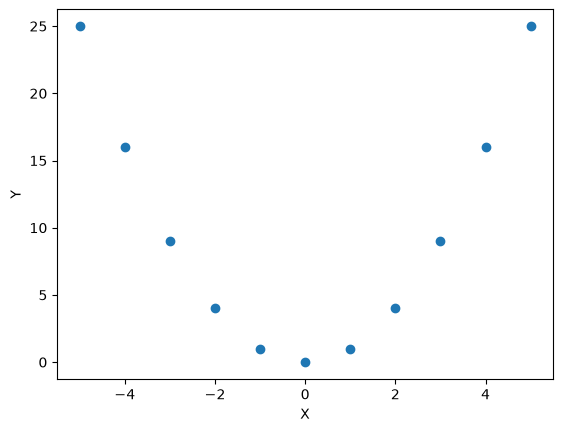

상관계수: 0.000
p-value: 1.000


In [13]:
import matplotlib.pyplot as plt
from scipy import stats

x = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]
y = [25, 16, 9, 4, 1, 0, 1, 4, 9, 16, 25]

r, p_value = stats.pearsonr(x, y)

plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

print(f"상관계수: {r:.3f}")
print(f"p-value: {p_value:.3f}")